### **Exercícios de Regressão – Linear, Múltipla e Polinomial**


### 1. Regressão Linear Simples – Exercícios

**Exercício 1:**

Neste exercício, vamos gerar dados seguindo o modelo:

$$y = 3x + 2 + w,$$


onde:

- $x$ é um vetor coluna com $N = 1000$ amostras geradas de uma distribuição uniforme no intervalo $[-1, 1]$;
- $w$ é um vetor coluna com $N$ amostras extraídas de uma distribuição normal Gaussiana com média zero e variância unitária.

O objetivo é ajustar um modelo de regressão linear e comparar os coeficientes reais com os estimados. Plote a função original, os dados ruidosos e a reta estimada.

---

**Exercício 2:**

Crie um conjunto de dados com $N = 100$ amostras seguindo o modelo:

$$y = \beta_0 + \beta_1 x + w,$$


onde:

- $x$ é um vetor coluna com $N$ elementos gerados a partir de uma distribuição **uniforme** no intervalo $[0, 10]$, representando os **anos de uso**;
- $\beta_0 = 50\,000$ é o preço inicial sem uso;
- $\beta_1 = -3\,000$ é a taxa de desvalorização por ano (relação linear decrescente);
- $w$ é um vetor coluna com $N$ elementos amostrados de uma **distribuição normal Gaussiana** com média zero e desvio padrão $\sigma = 2000$, representando ruído no preço.

Treine um modelo de regressão linear para estimar $\beta_0$ e $\beta_1$ e compare esses valores com os coeficientes reais. Plote a função original, os dados ruidosos e a reta estimada.

-----------------------------------------------------------
### 2. Regressão Linear Múltipla – Exercícios

**Exercício 3:**

Considere o modelo linear:

$$y = 5 + 3x_1 - 2x_2 + w,$$

onde:

- $x_1$ e $x_2$ são vetores coluna com $N = 1000$ amostras geradas de forma independente a partir de uma distribuição uniforme no intervalo $[-1, 1]$;
- $w$ é um vetor coluna com $N$ amostras extraídas de uma distribuição normal Gaussiana com média zero e desvio padrão $\sigma = 0.5$.

O objetivo é ajustar um modelo de regressão linear múltipla e comparar os coeficientes reais com os estimados. Plote a função original, os dados ruidosos e a reta estimada.

**Exercício 4:**

Neste exercício, vamos investigar o impacto da normalização quando trabalhamos com variáveis que possuem **escalas muito diferentes**.

Considere:

- $x_1$: variável na escala de **0 a 10**.  
- $x_2$: variável na escala de **0 a 10.000**.

O modelo real utilizado para gerar os dados será:

$$y = 4x_1 + 0.002x_2 + w,$$

onde o ruído $w$ segue uma distribuição normal Gaussiana com média zero e desvio padrão $\sigma = 5$.

O objetivo é:

1. Treinar um **modelo sem normalização**.  
2. Treinar um **modelo com normalização via StandardScaler**.  
3. Comparar coeficientes e plotar a função original, os dados ruidosos e a reta estimada.  
4. Explicar por que a normalização impacta os coeficientes.

-----------------------------------------------------------
 ### 3. Regressão Polinomial – Exercícios

**Exercício 5:**
Considere o seguinte modelo gerador de dados:

$$
y = 2x^2 - x + 1 + w,
$$

onde:

- $x$ é um vetor coluna com $N = 1000$ amostras geradas de forma independente a partir de uma distribuição uniforme no intervalo $[-1, 1]$;
- $w$ é um vetor coluna com $N$ amostras extraídas de uma distribuição normal Gaussiana com média zero e desvio padrão $\sigma = 0.5$.

O objetivo é analisar o comportamento da regressão polinomial ao tentar aproximar um modelo não linear verdadeiro utilizando diferentes graus de complexidade.
Treine modelos de regressão polinomial considerando as seguintes hipóteses:

- Grau 1 (modelo linear):

$$
y \approx \beta_0 + \beta_1 x
$$

- Grau 2 (modelo correto em relação ao processo gerador):

$$
y \approx \beta_0 + \beta_1 x + \beta_2 x^2
$$

- Grau 3 (modelo superparametrizado):

$$
y \approx \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3
$$

**Objetivo:**

Comparar o desempenho dos três modelos em termos de:

- capacidade de aproximação da função verdadeira;
- plotar a função original, os dados ruidosos e a reta estimada.
- impacto da complexidade do modelo (underfitting vs. overfitting);
- influência do termo de ruído $w$ na estimativa dos coeficientes.

In [ ]:
#imports necessario

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler


#Seed global para manter os mesmos results

np.random.seed(42)

#Exercicio 1

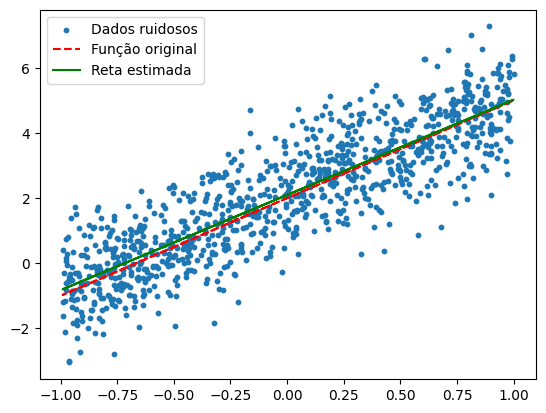

In [ ]:
#Qtd amostras
N = 1000

#Variavel de entrada
x = np.random.uniform(-1,1,N).reshape(-1,1)

#Ruido
w = (np.sqrt(1) * np.random.randn(N)).reshape(-1,1) #Nao precisaria do np.sqrt(1) mas so pra reforçar o conceito de variancia e desvio padrao

#Função original
y = 3*x + 2

#funcao ruidosa

y_noisy = y + w

model = LinearRegression()

model.fit(x, y_noisy)

y_pred = model.predict(x)

plt.scatter(x, y_noisy, label='Dados ruidosos',s=10)
plt.plot(x, y, 'r--', label='Função original')
plt.plot(x, y_pred, 'g-', label='Reta estimada')
plt.legend()
plt.show()

#Exercicio 2

Intercepto real: 50000 | Estimado: 50430.19
Coeficiente real: -3000 | Estimado: -3091.95


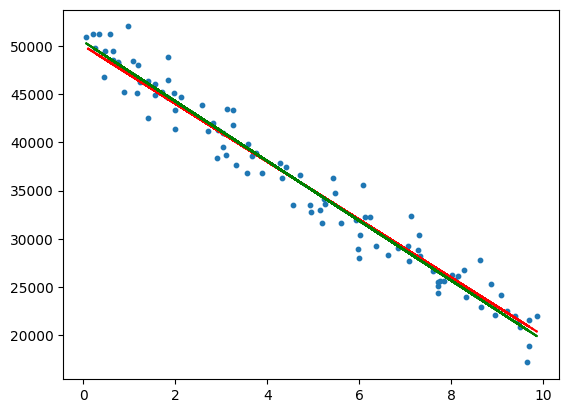

In [ ]:
np.random.seed(42)

#Numero de samples
N = 100

#variaveis
beta0 = 50000
beta1 = -3000

#entrada
x = np.random.uniform(0,10,N).reshape(-1,1)
w = (2000 * np.random.randn(N)).reshape(-1,1)

#Funcao original
y = beta0 + beta1*x #  b + ax

#funcao ruido
y_noisy = y + w

#definindo e treinando modelo
model = LinearRegression()

model.fit(x, y_noisy)

y_pred = model.predict(x)

print(f"Intercepto real: {beta0} | Estimado: {model.intercept_[0]:.2f}")
print(f"Coeficiente real: {beta1} | Estimado: {model.coef_[0][0]:.2f}")


plt.scatter(x, y_noisy, label='Dados ruidosos',s=10)
plt.plot(x, y, 'r--', label='Função original')
plt.plot(x, y_pred, 'g-', label='Reta estimada')
plt.show()


#Exercicio 3

Intercepto real: 5 | Estimado: 5.050
Coeficiente 1 real: 3 | Estimado: 2.915
Coeficiente 2 real: -2 | Estimado: -1.820


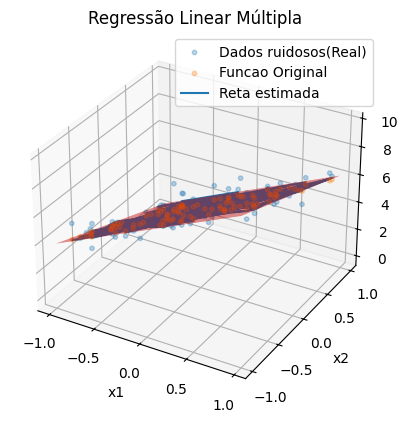

In [ ]:
np.random.seed(42)

#Valores de entrada
x1, x2 = np.random.uniform(-1,1,N).reshape(-1,1), np.random.uniform(-1,1,N).reshape(-1,1)

#ruido
w = 0.5 * np.random.randn(N).reshape(-1,1)

#Funcao original
y = 5 + 3*x1 - 2*x2

#Funcao ruido
y_noisy = y + w

#Transformar x1 e x2 em uma matriz
X = np.column_stack((x1, x2))

#Definindo e treinando modelo
model = LinearRegression()

model.fit(X, y_noisy)

#Predicao do modelo
y_pred = model.predict(X)

#Coeficientes encontrados
a_hat1 = model.coef_[0][0]
a_hat2 = model.coef_[0][1]
b_hat = model.intercept_[0]


#Comparando coeficientes
print(f"Intercepto real: {5} | Estimado: {model.intercept_[0]:.3f}")
print(f"Coeficiente 1 real: {3} | Estimado: {model.coef_[0][0]:.3f}")
print(f"Coeficiente 2 real: {-2} | Estimado: {model.coef_[0][1]:.3f}")

#Plot

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.scatter(x1,x2, y_noisy,alpha=0.3, label='Dados ruidosos(Real)',s=10)
ax.scatter(x1,x2, y,alpha=0.3, label='Funcao Original',s=10)
ax.plot(x1,x2,y_pred, label= "Reta estimada")

# Criando um grid para o plano
x1_grid, x2_grid = np.meshgrid(
    np.linspace(min(x1), max(x1), 40),
    np.linspace(min(x2), max(x2), 40))

# Plano previsto
y_grid = (b_hat
    + a_hat1 * x1_grid
    + a_hat2 * x2_grid)

# Superfície do plano
ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.5, color='red')
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")
ax.set_title("Regressão Linear Múltipla")
plt.legend()
plt.show()

#Exercicio 4

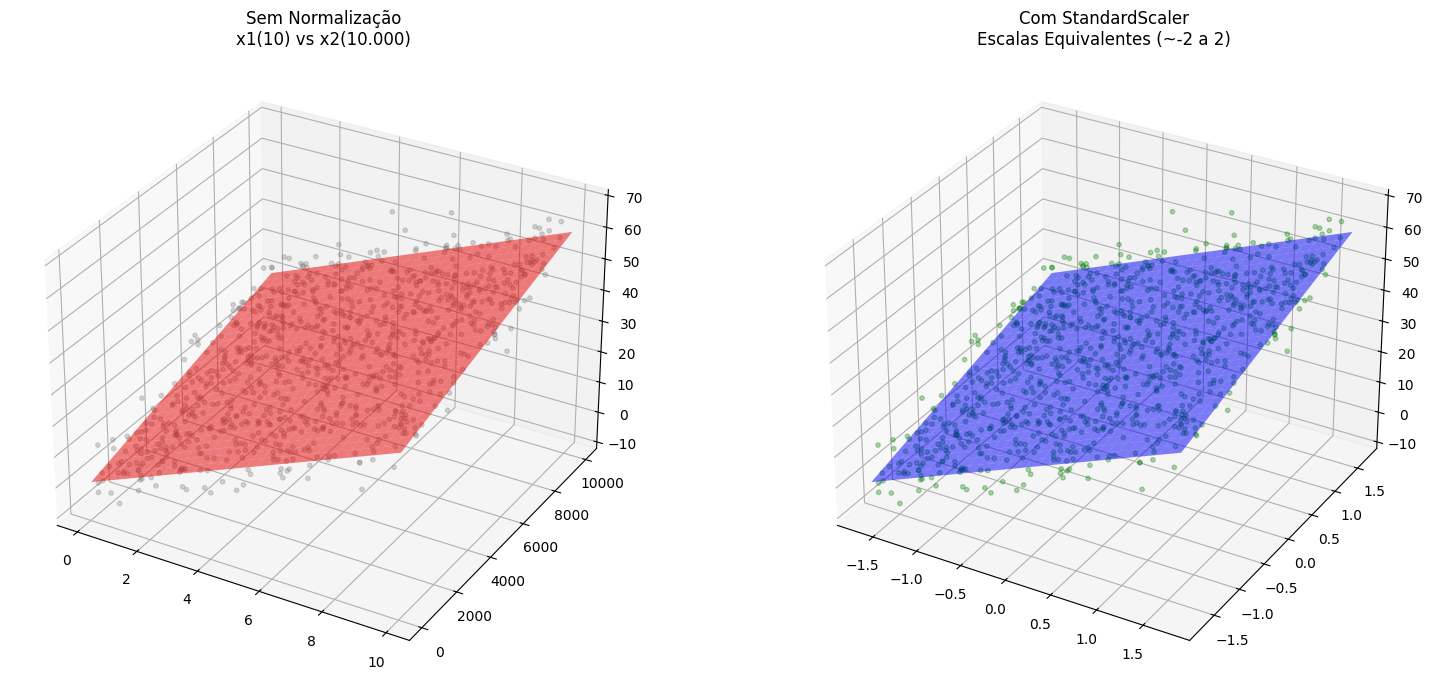

REAL:        a1 = 4.000  | a2 = 0.002
ESTIMADO:    a1 = 3.983  | a2 = 0.002 (Sem Norma)
NORMALIZADO: a1 = 11.630 | a2 = 5.836 (Com Norma)
A normalização impacta os coeficientes porque altera a unidade de medida do modelo: Sem Normalização: O coeficiente mede o peso de 1 unidade bruta (ex: 1 km ou 1 real). Números grandes (10.000) exigem pesos minúsculos 0,002
para não quebrarem a conta.Com Normalização: O peso passa a ser por 1 desvio padrão. Como todas as variáveis agora têm o mesmo tamanho visual, os coeficientes refletem a importância real de cada uma.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Configurações e Dados
N = 1000
np.random.seed(42)

# Variáveis de entrada (Escalas muito diferentes)
x1 = np.random.uniform(0, 10, N).reshape(-1, 1)        # 0 a 10
x2 = np.random.uniform(0, 10000, N).reshape(-1, 1)     # 0 a 10.000

# Ruído
w = 5 * np.random.randn(N).reshape(-1, 1)

# Função real: y = 4*x1 + 0.002*x2 + ruído
y_noisy = 4*x1 + 0.002*x2 + w

# Normalização (Usando dois scalers para manter x1 e x2 separados)
scaler1 = StandardScaler()
scaler2 = StandardScaler()

x1_norm = scaler1.fit_transform(x1)
x2_norm = scaler2.fit_transform(x2)

# Treinamento

# Modelo SEM Normalização
model_raw = LinearRegression()
model_raw.fit(np.column_stack((x1, x2)), y_noisy)

# Modelo COM Normalização
model_norm = LinearRegression()
model_norm.fit(np.column_stack((x1_norm, x2_norm)), y_noisy)

# Extração de Coeficientes
# Sem Norma
b_raw = model_raw.intercept_[0]
a1_raw = model_raw.coef_[0][0]
a2_raw = model_raw.coef_[0][1]

# Com Norma
b_norm = model_norm.intercept_[0]
a1_norm = model_norm.coef_[0][0]
a2_norm = model_norm.coef_[0][1]

# Visualização Lado a Lado
fig = plt.figure(figsize=(16, 7))

# --- GRÁFICO 1: SEM NORMALIZAÇÃO ---
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(x1, x2, y_noisy, alpha=0.3, s=10, color='gray')

x1_range = np.linspace(x1.min(), x1.max(), 30)
x2_range = np.linspace(x2.min(), x2.max(), 30)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)
y_grid = b_raw + a1_raw * x1_grid + a2_raw * x2_grid

ax1.plot_surface(x1_grid, x2_grid, y_grid, color='red', alpha=0.5)
ax1.set_title("Sem Normalização\nx1(10) vs x2(10.000)")

# --- GRÁFICO 2: COM NORMALIZAÇÃO ---
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(x1_norm, x2_norm, y_noisy, alpha=0.3, s=10, color='green')

xn1_range = np.linspace(x1_norm.min(), x1_norm.max(), 30)
xn2_range = np.linspace(x2_norm.min(), x2_norm.max(), 30)
xn1_grid, xn2_grid = np.meshgrid(xn1_range, xn2_range)
y_norm_grid = b_norm + a1_norm * xn1_grid + a2_norm * xn2_grid

ax2.plot_surface(xn1_grid, xn2_grid, y_norm_grid, color='blue', alpha=0.5)
ax2.set_title("Com StandardScaler\nEscalas Equivalentes (~-2 a 2)")

plt.tight_layout()
plt.show()

# Comparação de Coeficientes
print(f"REAL:        a1 = 4.000  | a2 = 0.002")
print(f"ESTIMADO:    a1 = {a1_raw:.3f}  | a2 = {a2_raw:.3f} (Sem Norma)")
print(f"NORMALIZADO: a1 = {a1_norm:.3f} | a2 = {a2_norm:.3f} (Com Norma)")

print("A normalização impacta os coeficientes porque altera a unidade de medida do modelo: Sem Normalização: O coeficiente mede o peso de 1 unidade bruta (ex: 1 km ou 1 real). Números grandes (10.000) exigem pesos minúsculos 0,002")
print("para não quebrarem a conta.Com Normalização: O peso passa a ser por 1 desvio padrão. Como todas as variáveis agora têm o mesmo tamanho visual, os coeficientes refletem a importância real de cada uma.")

#Exercicio 5

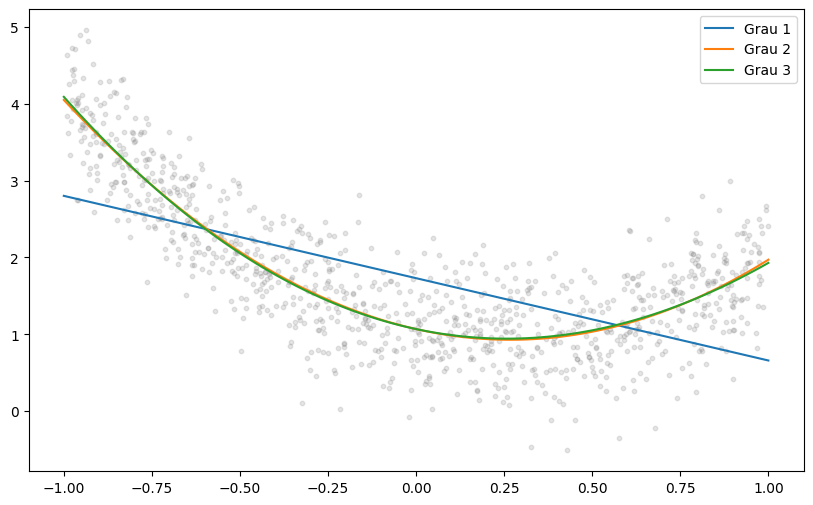

REAL:       beta0=1.0 | beta1=-1.0 | beta2=2.0 | beta3=0.0
MODELO 2:   b0=1.07 | b1=-1.04 | b2=1.94
MODELO 3:   b0=1.07 | b1=-0.98 | b2=1.94 | b3=-0.10


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Config
N = 1000
np.random.seed(42)

# Entrada x entre -1 e 1
x = np.random.uniform(-1, 1, N).reshape(-1, 1)

# Ruído (sigma = 0.5)
w = 0.5 * np.random.randn(N).reshape(-1, 1)

# Função real: y = 2x² - x + 1
y_real = 2*(x**2) - x + 1
y_noisy = y_real + w

poly2 = PolynomialFeatures(degree=2, include_bias=False)
poly3 = PolynomialFeatures(degree=3, include_bias=False)

X2 = poly2.fit_transform(x) # Gera colunas: [x, x²]
X3 = poly3.fit_transform(x) # Gera colunas: [x, x², x³]

# Treinando os Modelos
model1 = LinearRegression().fit(x, y_noisy)   # Grau 1 (original)
model2 = LinearRegression().fit(X2, y_noisy)  # Grau 2
model3 = LinearRegression().fit(X3, y_noisy)  # Grau 3

# Plotando
x_range = np.linspace(-1, 1, 100).reshape(-1, 1)

plt.figure(figsize=(10, 6))

plt.scatter(x, y_noisy, alpha=0.2, color='gray', s=10)
plt.plot(x_range, model1.predict(x_range), label='Grau 1')
plt.plot(x_range, model2.predict(poly2.transform(x_range)), label='Grau 2')
plt.plot(x_range, model3.predict(poly3.transform(x_range)), label='Grau 3')

plt.legend()
plt.show()

# Comparação de Coeficientes (
print(f"REAL:       beta0=1.0 | beta1=-1.0 | beta2=2.0 | beta3=0.0")
print(f"MODELO 2:   b0={model2.intercept_[0]:.2f} | b1={model2.coef_[0][0]:.2f} | b2={model2.coef_[0][1]:.2f}")
print(f"MODELO 3:   b0={model3.intercept_[0]:.2f} | b1={model3.coef_[0][0]:.2f} | b2={model3.coef_[0][1]:.2f} | b3={model3.coef_[0][2]:.2f}")


# A análise demonstra que o modelo de Grau 1 sofre de underfitting, sendo simples demais para capturar a curvatura real dos dados.
# O Grau 2 apresenta o ajuste ideal, pois coincide com a natureza quadrática do processo gerador.
# Já o Grau 3 ilustra o risco de overfitting, onde a complexidade excessiva pode levar o modelo a tratar o ruído aleatório como se fosse um padrão real.
# O termo de ruído (w) é o responsável por desviar os coeficientes estimados dos valores reais (2, -1 e 1), gerando incerteza e criando termos "fantasmas" (como o de x^3)
# que deveriam ser nulos, mas ganham pequenos valores devido à aleatoriedade, o que evidencia como o ruído limita a precisão absoluta das estimativas.